In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
iris_df=pd.read_csv('/content/Iris.csv')

In [ ]:
iris_df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
iris_df.shape

(150, 6)

In [ ]:
iris_df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [ ]:
x_variables=iris_df.iloc[:,1:5]
x_variables

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:
y_variables=iris_df.iloc[:,5]
y_variables

,Species
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa
...,...
145,Iris-virginica
146,Iris-virginica
147,Iris-virginica
148,Iris-virginica


In [ ]:
sc=StandardScaler()
transformed_df=sc.fit_transform(x_variables)
transformed_df #standardizing the x variables

array([[-9.00681170e-01,  1.03205722e+00, -1.34127240e+00,
        -1.31297673e+00],
       [-1.14301691e+00, -1.24957601e-01, -1.34127240e+00,
        -1.31297673e+00],
       [-1.38535265e+00,  3.37848329e-01, -1.39813811e+00,
        -1.31297673e+00],
       [-1.50652052e+00,  1.06445364e-01, -1.28440670e+00,
        -1.31297673e+00],
       [-1.02184904e+00,  1.26346019e+00, -1.34127240e+00,
        -1.31297673e+00],
       [-5.37177559e-01,  1.95766909e+00, -1.17067529e+00,
        -1.05003079e+00],
       [-1.50652052e+00,  8.00654259e-01, -1.34127240e+00,
        -1.18150376e+00],
       [-1.02184904e+00,  8.00654259e-01, -1.28440670e+00,
        -1.31297673e+00],
       [-1.74885626e+00, -3.56360566e-01, -1.34127240e+00,
        -1.31297673e+00],
       [-1.14301691e+00,  1.06445364e-01, -1.28440670e+00,
        -1.44444970e+00],
       [-5.37177559e-01,  1.49486315e+00, -1.28440670e+00,
        -1.31297673e+00],
       [-1.26418478e+00,  8.00654259e-01, -1.22754100e+00,
      

In [ ]:
cov_matrix=np.cov(transformed_df.T)
cov_matrix

array([[ 1.00671141, -0.11010327,  0.87760486,  0.82344326],
       [-0.11010327,  1.00671141, -0.42333835, -0.358937  ],
       [ 0.87760486, -0.42333835,  1.00671141,  0.96921855],
       [ 0.82344326, -0.358937  ,  0.96921855,  1.00671141]])

In [ ]:
eigen_values,eigen_vectors=np.linalg.eig(cov_matrix)

In [ ]:
eigen_pairs=[(np.abs(eigen_values[i]), eigen_vectors[:,i]) for i in range(len(eigen_values))]
print("Eigen arranged in descending order:")
for i in eigen_pairs:
  print(i[0])

Eigen arranged in descending order:
2.930353775589317
0.9274036215173419
0.14834222648163944
0.02074601399559593


In [ ]:
pca=PCA()

In [ ]:
pca=pca.fit(transformed_df)

In [ ]:
explained_variance=pca.explained_variance_ratio_
explained_variance

array([0.72770452, 0.23030523, 0.03683832, 0.00515193])

<Axes: xlabel='Principal Component', ylabel='variance'>

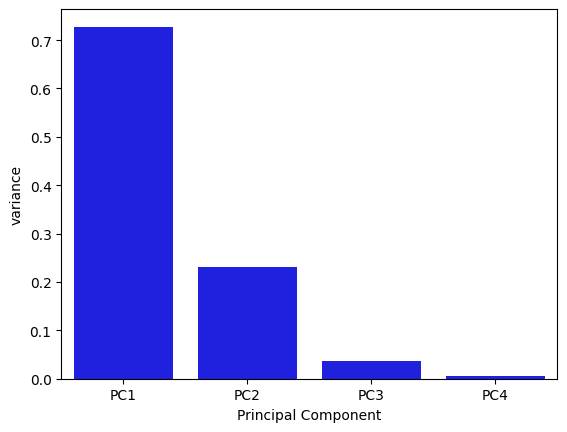

In [ ]:
#Creating a Dataframe to store variance explained by each principal component
dataframe=pd.DataFrame({'variance':pca.explained_variance_ratio_,
                        'Principal Component': ['PC1','PC2','PC3','PC4']})

#Visualizing the explained variance of each principal component using a bar plot
sns.barplot(x='Principal Component',y="variance", data=dataframe, color="b")

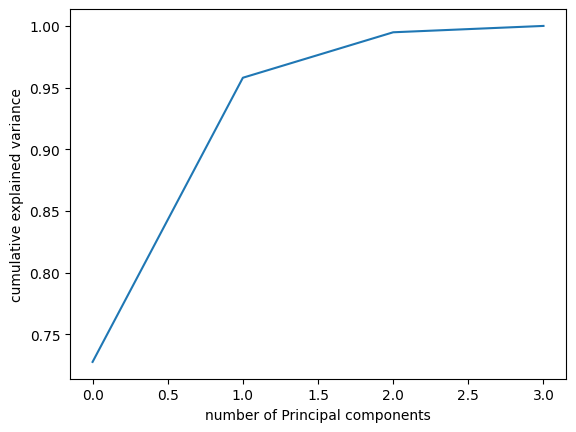

In [ ]:
#Plotting cumulative explained variance to determine optimal number of principal component
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of Principal components')
plt.ylabel('cumulative explained variance')
plt.show()

In [ ]:
#Creating a PCA model for 2D dimensionality reduction
pca_2=PCA(n_components=2)
#learning the top 2 principal components from the data
pca_2_result=pca_2.fit_transform(transformed_df)
#projecting the feature data onto the 2 principal components
pca_2d=pca_2.transform(x_variables)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(


In [ ]:
#Encoding Iris species label onto numerical values
iris_df['species']=iris_df['Species'].replace({'Iris-setosa':0,'Iris-versicolor':1,'Iris-virginica':2})

/tmp/ipython-input-2017721449.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  iris_df['species']=iris_df['Species'].replace({'Iris-setosa':0,'Iris-versicolor':1,'Iris-virginica':2})


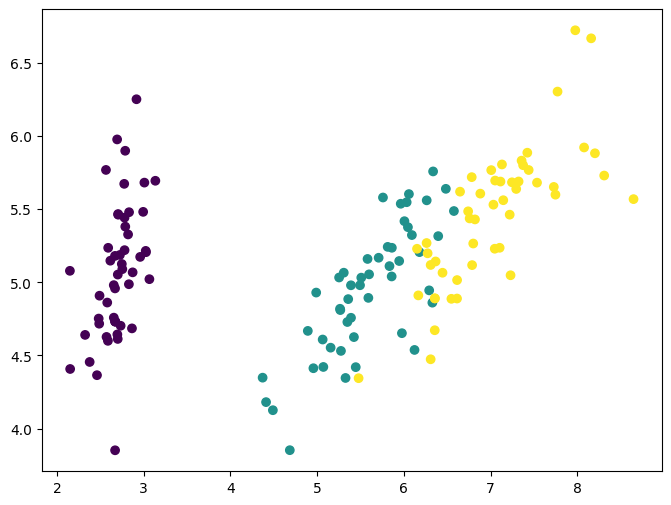

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(pca_2d[:,0], pca_2d[:,1], c=iris_df['species'])
plt.show()

In [ ]:
#Initializing PCA to retain all 4 principal components
#Creating a PCA model with four components to preserve full feature variance
pca_4=PCA(n_components=4)

#Fitting the PCA model on the transformed dataset
#Learning the principal components from the standardized data
pca_4_result=pca_4.fit_transform(transformed_df)
#Projectig the original features into the PCA-transformed feature space
pca_4d=pca_4.transform(x_variables)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(


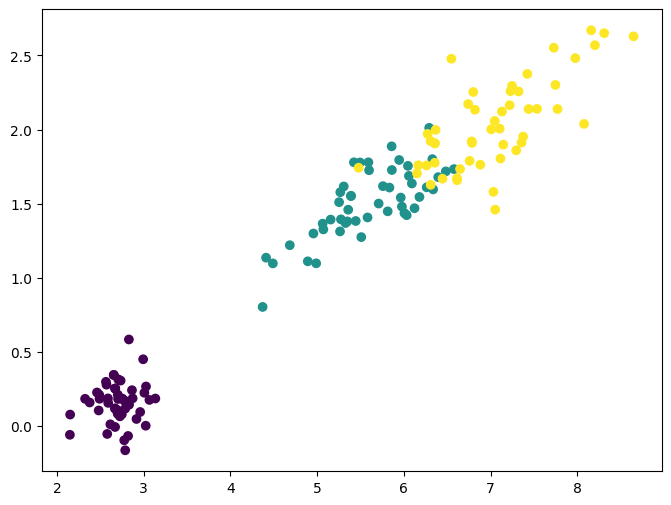

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(pca_4d[:,0], pca_4d[:,3], c=iris_df['species'])
plt.show()